In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [42]:
product_category_translation = pd.read_csv('product_category_name_translation.csv')
sellers = pd.read_csv('olist_sellers_dataset.csv')
products = pd.read_csv('olist_products_dataset.csv')
orders = pd.read_csv('olist_orders_dataset.csv')
order_reviews = pd.read_csv('olist_order_reviews_dataset.csv')
order_payments = pd.read_csv('olist_order_payments_dataset.csv')
order_items = pd.read_csv('olist_order_items_dataset.csv')
geolocation= pd.read_csv('olist_geolocation_dataset.csv')
customers = pd.read_csv('olist_customers_dataset.csv')

In [43]:
products.columns  

Index(['product_id', 'product_category_name', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm'],
      dtype='object')

In [44]:
orders["order_estimated_delivery_date"] = pd.to_datetime(orders["order_estimated_delivery_date"], errors="coerce")
orders["order_delivered_customer_date"] = pd.to_datetime(orders["order_delivered_customer_date"], errors="coerce")
orders["order_purchase_timestamp"] = pd.to_datetime(orders["order_purchase_timestamp"], errors="coerce")
orders["order_approved_at"] = pd.to_datetime(orders["order_approved_at"], errors="coerce")
orders["order_delivered_carrier_date"] = pd.to_datetime(orders["order_delivered_carrier_date"], errors="coerce")


In [45]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  datetime64[ns]
 5   order_delivered_carrier_date   97658 non-null  datetime64[ns]
 6   order_delivered_customer_date  96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  datetime64[ns]
dtypes: datetime64[ns](5), object(3)
memory usage: 6.1+ MB


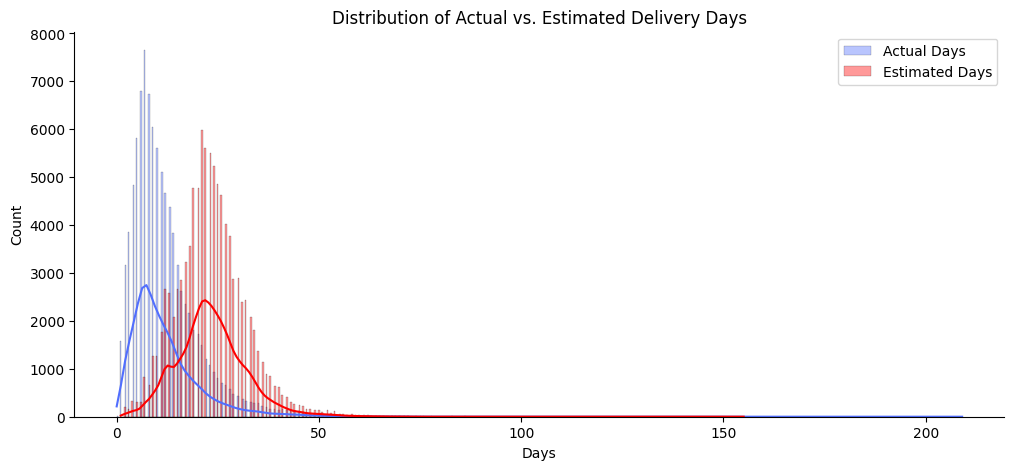

In [46]:
plt.figure(figsize=(12, 5))
orders["actual_days"] = (orders["order_delivered_customer_date"] - orders["order_purchase_timestamp"]).dt.days
orders["estimated_days"] = (orders["order_estimated_delivery_date"] - orders["order_purchase_timestamp"]).dt.days
sns.histplot(orders["actual_days"], color="#516efe", label="Actual Days", kde=True, alpha=0.4)
sns.histplot(orders["estimated_days"], color="#ff0000", label="Estimated Days", kde=True, alpha=0.4)
sns.despine(right=True, top=True)
plt.title("Distribution of Actual vs. Estimated Delivery Days")
plt.xlabel("Days")
plt.legend()
plt.savefig("distribution_plot.pdf", bbox_inches='tight')
plt.show()

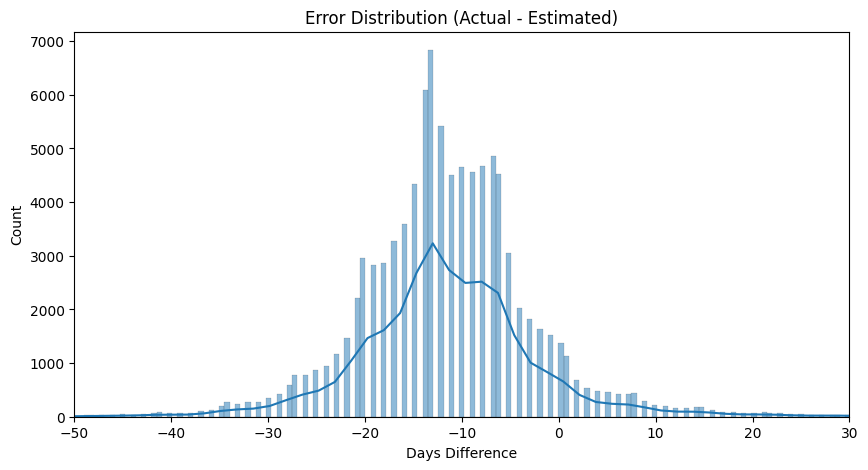

In [47]:
plt.figure(figsize=(10,5))

orders["error"] = orders["actual_days"] - orders["estimated_days"]

sns.histplot(orders["error"], kde=True)
plt.xlim(-50, 30)
plt.title("Error Distribution (Actual - Estimated)")
plt.xlabel("Days Difference")

plt.show()

In [48]:

orders_clean = orders.dropna(subset=["actual_days", "estimated_days"])

total_orders = orders_clean.shape[0]

early_orders = orders_clean[orders_clean["actual_days"] < orders_clean["estimated_days"]]
early_count = early_orders.shape[0]
early_percentage = (early_count / total_orders) * 100

late_orders = orders_clean[orders_clean["actual_days"] > orders_clean["estimated_days"]]
late_count = late_orders.shape[0]
late_percentage = (late_count / total_orders) * 100

on_time_orders = orders_clean[orders_clean["actual_days"] == orders_clean["estimated_days"]]
on_time_count = on_time_orders.shape[0]
on_time_percentage = (on_time_count / total_orders) * 100

print("Early Orders Count:", early_count)
print("Early Orders Percentage: {:.2f}%".format(early_percentage))

print("Late Orders Count:", late_count)
print("Late Orders Percentage: {:.2f}%".format(late_percentage))

print("On Time Orders Count:", on_time_count)
print("On Time Orders Percentage: {:.2f}%".format(on_time_percentage))

Early Orders Count: 87788
Early Orders Percentage: 90.99%
Late Orders Count: 7308
Late Orders Percentage: 7.57%
On Time Orders Count: 1380
On Time Orders Percentage: 1.43%


In [49]:

orders["delay"] = orders["actual_days"] - orders["estimated_days"]

avg_delay = orders["delay"].mean()

print("Average Delay:", round(avg_delay, 2), "days")

Average Delay: -11.28 days


In [50]:
geo = geolocation.groupby('geolocation_zip_code_prefix').agg({
    'geolocation_lat': 'mean',
    'geolocation_lng': 'mean'
}).reset_index()
geo

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng
0,1001,-23.550190,-46.634024
1,1002,-23.548146,-46.634979
2,1003,-23.548994,-46.635731
3,1004,-23.549799,-46.634757
4,1005,-23.549456,-46.636733
...,...,...,...
19010,99960,-27.953722,-52.025511
19011,99965,-28.183372,-52.039850
19012,99970,-28.343766,-51.874689
19013,99980,-28.389129,-51.843836


In [51]:
df = orders.merge(customers, on='customer_id') \
           .merge(order_items, on='order_id') \
           .merge(sellers, on='seller_id') \
           .merge(products, on='product_id') \
           .merge(product_category_translation, on='product_category_name')
df

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,actual_days,estimated_days,...,seller_state,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.0,15,...,SP,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,housewares
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13.0,19,...,SP,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0,perfumery
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9.0,26,...,SP,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0,auto
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,13.0,26,...,MG,pet_shop,59.0,468.0,3.0,450.0,30.0,10.0,20.0,pet_shop
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2.0,12,...,SP,papelaria,38.0,316.0,4.0,250.0,51.0,15.0,15.0,stationery
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
111018,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02,22.0,23,...,SP,bebes,52.0,828.0,4.0,4950.0,40.0,10.0,40.0,baby
111019,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27,24.0,30,...,SP,eletrodomesticos_2,51.0,500.0,2.0,13300.0,32.0,90.0,22.0,home_appliances_2
111020,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15,17.0,37,...,MG,informatica_acessorios,59.0,1893.0,1.0,6550.0,20.0,20.0,20.0,computers_accessories
111021,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15,17.0,37,...,MG,informatica_acessorios,59.0,1893.0,1.0,6550.0,20.0,20.0,20.0,computers_accessories


In [52]:
df = df.merge(geo,
              left_on='customer_zip_code_prefix',
              right_on='geolocation_zip_code_prefix',
              how='left')

df = df.rename(columns={
    'geolocation_lat': 'customer_lat',
    'geolocation_lng': 'customer_lng'
})
df

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,actual_days,estimated_days,...,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english,geolocation_zip_code_prefix,customer_lat,customer_lng
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.0,15,...,268.0,4.0,500.0,19.0,8.0,13.0,housewares,3149.0,-23.576983,-46.587161
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13.0,19,...,178.0,1.0,400.0,19.0,13.0,19.0,perfumery,47813.0,-12.177924,-44.660711
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9.0,26,...,232.0,1.0,420.0,24.0,19.0,21.0,auto,75265.0,-16.745150,-48.514783
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,13.0,26,...,468.0,3.0,450.0,30.0,10.0,20.0,pet_shop,59296.0,-5.774190,-35.271143
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2.0,12,...,316.0,4.0,250.0,51.0,15.0,15.0,stationery,9195.0,-23.676370,-46.514627
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
111018,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02,22.0,23,...,828.0,4.0,4950.0,40.0,10.0,40.0,baby,11722.0,-24.001500,-46.449864
111019,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27,24.0,30,...,500.0,2.0,13300.0,32.0,90.0,22.0,home_appliances_2,45920.0,-17.898358,-39.373630
111020,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15,17.0,37,...,1893.0,1.0,6550.0,20.0,20.0,20.0,computers_accessories,28685.0,-22.562825,-42.694574
111021,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15,17.0,37,...,1893.0,1.0,6550.0,20.0,20.0,20.0,computers_accessories,28685.0,-22.562825,-42.694574


In [53]:
df = df.merge(geo,
              left_on='seller_zip_code_prefix',
              right_on='geolocation_zip_code_prefix',
              how='left')

df = df.rename(columns={
    'geolocation_lat': 'seller_lat',
    'geolocation_lng': 'seller_lng'
})
df

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,actual_days,estimated_days,...,product_length_cm,product_height_cm,product_width_cm,product_category_name_english,geolocation_zip_code_prefix_x,customer_lat,customer_lng,geolocation_zip_code_prefix_y,seller_lat,seller_lng
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.0,15,...,19.0,8.0,13.0,housewares,3149.0,-23.576983,-46.587161,9350.0,-23.680729,-46.444238
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13.0,19,...,19.0,13.0,19.0,perfumery,47813.0,-12.177924,-44.660711,31570.0,-19.807681,-43.980427
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9.0,26,...,24.0,19.0,21.0,auto,75265.0,-16.745150,-48.514783,14840.0,-21.363502,-48.229601
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,13.0,26,...,30.0,10.0,20.0,pet_shop,59296.0,-5.774190,-35.271143,31842.0,-19.837682,-43.924053
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2.0,12,...,51.0,15.0,15.0,stationery,9195.0,-23.676370,-46.514627,8752.0,-23.543395,-46.262086
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
111018,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02,22.0,23,...,40.0,10.0,40.0,baby,11722.0,-24.001500,-46.449864,17602.0,-21.930548,-50.498348
111019,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27,24.0,30,...,32.0,90.0,22.0,home_appliances_2,45920.0,-17.898358,-39.373630,8290.0,-23.553642,-46.452661
111020,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15,17.0,37,...,20.0,20.0,20.0,computers_accessories,28685.0,-22.562825,-42.694574,37175.0,-20.940578,-45.827237
111021,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15,17.0,37,...,20.0,20.0,20.0,computers_accessories,28685.0,-22.562825,-42.694574,37175.0,-20.940578,-45.827237


In [54]:
df

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,actual_days,estimated_days,...,product_length_cm,product_height_cm,product_width_cm,product_category_name_english,geolocation_zip_code_prefix_x,customer_lat,customer_lng,geolocation_zip_code_prefix_y,seller_lat,seller_lng
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.0,15,...,19.0,8.0,13.0,housewares,3149.0,-23.576983,-46.587161,9350.0,-23.680729,-46.444238
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13.0,19,...,19.0,13.0,19.0,perfumery,47813.0,-12.177924,-44.660711,31570.0,-19.807681,-43.980427
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9.0,26,...,24.0,19.0,21.0,auto,75265.0,-16.745150,-48.514783,14840.0,-21.363502,-48.229601
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,13.0,26,...,30.0,10.0,20.0,pet_shop,59296.0,-5.774190,-35.271143,31842.0,-19.837682,-43.924053
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2.0,12,...,51.0,15.0,15.0,stationery,9195.0,-23.676370,-46.514627,8752.0,-23.543395,-46.262086
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
111018,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02,22.0,23,...,40.0,10.0,40.0,baby,11722.0,-24.001500,-46.449864,17602.0,-21.930548,-50.498348
111019,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27,24.0,30,...,32.0,90.0,22.0,home_appliances_2,45920.0,-17.898358,-39.373630,8290.0,-23.553642,-46.452661
111020,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15,17.0,37,...,20.0,20.0,20.0,computers_accessories,28685.0,-22.562825,-42.694574,37175.0,-20.940578,-45.827237
111021,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15,17.0,37,...,20.0,20.0,20.0,computers_accessories,28685.0,-22.562825,-42.694574,37175.0,-20.940578,-45.827237


In [55]:
from geopy.distance import geodesic

def calculate_distance(row):
    customer_coords = (row['customer_lat'], row['customer_lng'])
    seller_coords = (row['seller_lat'], row['seller_lng'])
    return geodesic(customer_coords, seller_coords).km

df = df.dropna(subset=['customer_lat', 'customer_lng', 'seller_lat', 'seller_lng']).copy()
df['distance_km'] = df.apply(calculate_distance, axis=1)

In [56]:
df['distance_km'].describe()

count    110476.000000
mean        596.300791
std         588.007725
min           0.000000
25%         185.689003
50%         431.977194
75%         791.179558
max        8652.119722
Name: distance_km, dtype: float64

In [57]:
df = df[(df['distance_km'] > 0) & (df['distance_km'] < 2000)]

In [58]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 104166 entries, 0 to 111022
Data columns (total 41 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       104166 non-null  object        
 1   customer_id                    104166 non-null  object        
 2   order_status                   104166 non-null  object        
 3   order_purchase_timestamp       104166 non-null  datetime64[ns]
 4   order_approved_at              104154 non-null  datetime64[ns]
 5   order_delivered_carrier_date   103073 non-null  datetime64[ns]
 6   order_delivered_customer_date  101984 non-null  datetime64[ns]
 7   order_estimated_delivery_date  104166 non-null  datetime64[ns]
 8   actual_days                    101984 non-null  float64       
 9   estimated_days                 104166 non-null  int64         
 10  error                          101984 non-null  float64       
 11  delay

In [59]:
df['delay_days'] = (
    df['order_delivered_customer_date'] - df['order_estimated_delivery_date']
).dt.days


In [ ]:
plt.figure(figsize=(10, 6))

sns.regplot(
    data=df,
    x="distance_km",
    y="delay_days",
    scatter_kws={"alpha": 0.3},
    line_kws={"color": "red"}
)

plt.title("Distance vs Delay (Trend Line)")
plt.xlabel("Distance (km)")
plt.ylabel("Delay (days)")
plt.savefig("distance_vs_delay.pdf", bbox_inches='tight')
plt.show()

the delivery time gap is highly concentrated around zero, indicating generally accurate estimations. However, the slight negative skew suggests a systematic overestimation of delivery times, where orders tend to arrive earlier than expected. A small number of extreme positive outliers indicate occasional severe delays likely caused by operational or external factors such as traffic or pickup inefficiencies